# Food & Restaurant Recommendation System

**Portfolio project — recommendation systems, personalization and business thinking**

This project builds a restaurant recommendation workflow using a **synthetic portfolio dataset**. It demonstrates content-based filtering, implicit user feedback, personalization, cold-start handling and offline evaluation.

> **Data note:** The data is synthetic and is not Swiggy internal data.


## 1. Business Problem

A food-delivery platform can have thousands of restaurants available to a user. The objective is to recommend restaurants relevant to a user's demonstrated interests while providing a fallback for users with no history.

**Workflow:** Business problem → behavioral data → representation → similarity → personalization → evaluation → business recommendations


In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT=Path.cwd()
if ROOT.name=="notebooks": ROOT=ROOT.parent
sys.path.append(str(ROOT/"src"))
from recommender import load_data, build_content_model, popularity_scores, content_recommend, user_profile_recommend

restaurants, interactions=load_data(ROOT/"data")
print("Restaurants:",restaurants.shape)
print("Interactions:",interactions.shape)
display(restaurants.head())
display(interactions.head())


Restaurants: (300, 10)
Interactions: (13897, 4)


,restaurant_id,restaurant_name,cuisine,area,price_level,rating,delivery_time_min,ambience,dietary_type,tags
0,1,Restaurant 001,North Indian,East,3,4.66,33,Casual,Vegetarian,North Indian East Casual Vegetarian price_3
1,2,Restaurant 002,Cafe,Riverside,1,3.99,34,Premium,Vegetarian,Cafe Riverside Premium Vegetarian price_1
2,3,Restaurant 003,Biryani,Central,2,4.26,35,Cafe,Mixed,Biryani Central Cafe Mixed price_2
3,4,Restaurant 004,Mexican,Riverside,2,3.02,37,Family,Vegetarian,Mexican Riverside Family Vegetarian price_2
4,5,Restaurant 005,Mexican,Tech Park,3,3.58,44,Casual,Vegetarian,Mexican Tech Park Casual Vegetarian price_3


,user_id,restaurant_id,interaction_type,weight
0,1,286,view,1
1,1,230,view,1
2,1,115,click,3
3,1,65,view,1
4,1,80,view,1


## 2. Data Understanding & Quality

Restaurant metadata includes cuisine, area, price level, rating, delivery time, ambience and dietary type.

User behavior is represented as implicit feedback:
- **View** = weak signal
- **Click** = stronger interest
- **Order** = strongest signal in this portfolio dataset

Interaction weights are 1, 3 and 5 respectively.


In [5]:
print("Missing values:")
display(restaurants.isna().sum().to_frame("missing_count"))
print("Unique users:",interactions.user_id.nunique())
print("Unique restaurants:",interactions.restaurant_id.nunique())
display(interactions.interaction_type.value_counts().to_frame("count"))


Missing values:


,missing_count
restaurant_id,0
restaurant_name,0
cuisine,0
area,0
price_level,0
rating,0
delivery_time_min,0
ambience,0
dietary_type,0
tags,0


Unique users: 1000
Unique restaurants: 300


,count
interaction_type,
view,6674
click,3748
order,3475


## 3. Exploratory Analysis

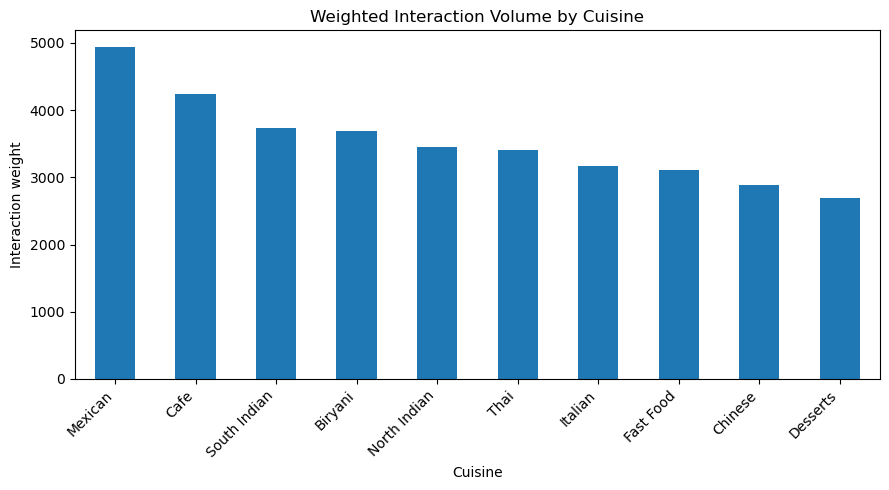

In [7]:
cuisine_interactions=(interactions.merge(restaurants[["restaurant_id","cuisine"]],on="restaurant_id")
.groupby("cuisine")["weight"].sum().sort_values(ascending=False))
plt.figure(figsize=(9,5)); cuisine_interactions.plot(kind="bar")
plt.title("Weighted Interaction Volume by Cuisine"); plt.ylabel("Interaction weight"); plt.xlabel("Cuisine")
plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.show()


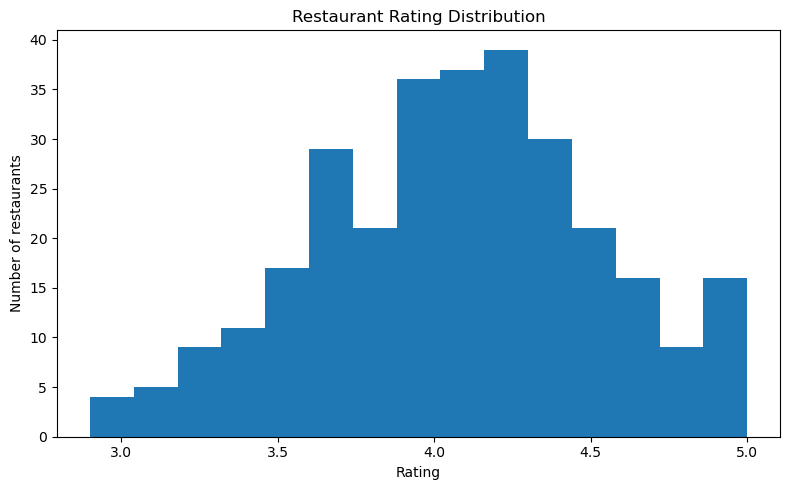

In [8]:
plt.figure(figsize=(8,5)); plt.hist(restaurants.rating,bins=15)
plt.title("Restaurant Rating Distribution"); plt.xlabel("Rating"); plt.ylabel("Number of restaurants")
plt.tight_layout(); plt.show()


## 4. Recommendation Strategy

**Popularity baseline:** ranks restaurants by total weighted interactions and handles cold-start users.

**Content-based filtering:** converts restaurant metadata into TF-IDF vectors and uses cosine similarity.

**Personalized profile:** aggregates similarity to restaurants in a user's interaction history, weighted by interaction strength, and excludes already-seen restaurants.


In [10]:
vectorizer,tfidf_matrix,similarity=build_content_model(restaurants)
pop_scores=popularity_scores(interactions)
print("TF-IDF matrix:",tfidf_matrix.shape)
print("Similarity matrix:",similarity.shape)
top_pop=restaurants.merge(pop_scores.rename("popularity_score"),left_on="restaurant_id",right_index=True,how="left").fillna({"popularity_score":0}).sort_values("popularity_score",ascending=False)
display(top_pop[["restaurant_name","cuisine","rating","popularity_score"]].head(10))


TF-IDF matrix: (300, 36)
Similarity matrix: (300, 300)


,restaurant_name,cuisine,rating,popularity_score
177,Restaurant 178,South Indian,4.90,260
193,Restaurant 194,Italian,4.88,233
99,Restaurant 100,South Indian,5.00,219
176,Restaurant 177,Cafe,5.00,214
265,Restaurant 266,Thai,4.89,212
73,Restaurant 074,South Indian,4.93,211
28,Restaurant 029,Thai,4.34,210
263,Restaurant 264,Fast Food,4.96,206
183,Restaurant 184,Biryani,4.66,204
65,Restaurant 066,Italian,5.00,201


## 5. Similar Restaurant Recommendations

In [12]:
seed_id=int(restaurants.iloc[0].restaurant_id)
print("Seed restaurant:",restaurants.iloc[0].restaurant_name)
display(content_recommend(restaurants,similarity,seed_id,10)[["restaurant_name","cuisine","area","price_level","rating","similarity_score"]])


Seed restaurant: Restaurant 001


,restaurant_name,cuisine,area,price_level,rating,similarity_score
6,Restaurant 007,North Indian,East,2,3.62,0.880264
32,Restaurant 033,North Indian,East,3,4.34,0.823628
242,Restaurant 243,North Indian,North,3,3.59,0.800492
278,Restaurant 279,North Indian,Riverside,3,4.11,0.734089
132,Restaurant 133,North Indian,Riverside,3,4.39,0.651635
102,Restaurant 103,Desserts,East,3,4.02,0.605080
220,Restaurant 221,South Indian,East,3,4.58,0.600892
117,Restaurant 118,South Indian,North,3,3.73,0.571565
146,Restaurant 147,North Indian,East,4,3.43,0.570096
78,Restaurant 079,Thai,East,2,4.24,0.563890


## 6. Personalized Recommendations

In [14]:
example_user=int(interactions.user_id.value_counts().index[0])
display(interactions[interactions.user_id==example_user].merge(restaurants[["restaurant_id","restaurant_name","cuisine"]],on="restaurant_id").head(10))
display(user_profile_recommend(restaurants,interactions,similarity,example_user,10)[["restaurant_name","cuisine","area","price_level","rating","recommendation_score"]])


,user_id,restaurant_id,interaction_type,weight,restaurant_name,cuisine
0,134,80,click,3,Restaurant 080,Biryani
1,134,159,view,1,Restaurant 159,Thai
2,134,85,click,3,Restaurant 085,Biryani
3,134,237,view,1,Restaurant 237,Biryani
4,134,269,order,5,Restaurant 269,Biryani
5,134,64,click,3,Restaurant 064,Fast Food
6,134,3,view,1,Restaurant 003,Biryani
7,134,33,click,3,Restaurant 033,North Indian
8,134,240,click,3,Restaurant 240,Biryani
9,134,26,view,1,Restaurant 026,Biryani


,restaurant_name,cuisine,area,price_level,rating,recommendation_score
98,Restaurant 099,Biryani,South,2,4.26,14.197716
97,Restaurant 098,Biryani,North,2,4.48,14.147913
122,Restaurant 123,Biryani,University,1,4.01,13.396788
203,Restaurant 204,Biryani,Riverside,2,4.08,12.999419
191,Restaurant 192,Biryani,Riverside,2,3.52,12.999419
192,Restaurant 193,Biryani,University,2,4.86,12.592744
190,Restaurant 191,Biryani,Airport,3,3.85,12.280535
174,Restaurant 175,Biryani,Market,1,3.97,12.223191
254,Restaurant 255,Biryani,Airport,1,4.80,11.823440
161,Restaurant 162,Biryani,North,1,3.37,11.701486


## 7. Offline Evaluation

A simple leave-one-out experiment holds out one interacted restaurant per eligible user and checks whether it appears in the top-K recommendations.

**Precision@K = hits / (evaluated users × K)**

**Hit Rate@K = users with a hit / evaluated users**

These are development metrics; production evaluation should also consider Recall/NDCG, coverage, diversity, latency and online A/B tests.


In [16]:
def precision_at_k(k=10):
    hits=evaluated=0
    rng_local=np.random.default_rng(123)
    ids=restaurants.restaurant_id.tolist()
    for _,hist in interactions.groupby("user_id"):
        if len(hist)<5: continue
        test=hist.iloc[rng_local.integers(0,len(hist))]
        train=hist.drop(test.name)
        score=pd.Series(0.0,index=range(len(restaurants)))
        for _,row in train.iterrows():
            idx=ids.index(int(row.restaurant_id)); score += similarity[idx]*float(row.weight)
        seen=set(train.restaurant_id.astype(int))
        for i,rid in enumerate(ids):
            if rid in seen: score.iloc[i]=-1
        top_idx=score.sort_values(ascending=False).head(k).index
        hits += int(int(test.restaurant_id) in set(restaurants.iloc[top_idx].restaurant_id.astype(int)))
        evaluated += 1
    return hits/(evaluated*k),hits/evaluated,evaluated

p10,hit10,n_eval=precision_at_k()
print(f"Evaluated users: {n_eval}")
print(f"Precision@10: {p10:.4f}")
print(f"Hit Rate@10: {hit10:.4f}")


Evaluated users: 1000
Precision@10: 0.0261
Hit Rate@10: 0.2610


## 8. Business Insights

- Personalization can reduce search effort by prioritizing restaurants matching demonstrated preferences.
- Orders are treated as stronger preference signals than views in this portfolio experiment.
- Popularity is a useful fallback for cold-start users.
- Recommendation systems should monitor coverage and diversity so a small set of popular restaurants does not dominate exposure.
- Offline metrics do not prove business impact; online experimentation is needed.

**These observations describe the synthetic portfolio dataset, not a real food-delivery company's internal behavior.**


## 9. Limitations & Production Improvements

**Limitations**
1. Synthetic data.
2. No real-time location, demand, availability or weather.
3. No production-scale collaborative filtering.
4. Offline evaluation does not establish business impact.

**Production improvements**
1. Hybrid collaborative + content-based models.
2. Two-stage candidate generation and ranking.
3. Context-aware features.
4. Diversity and freshness constraints.
5. Cold-start strategies.
6. Online A/B testing using CTR, conversion, GMV and retention.
7. Monitoring for drift, latency and recommendation coverage.


## 10. Interview Talking Points

**Why TF-IDF?** It converts metadata into numerical vectors for similarity-based retrieval.

**Why cosine similarity?** It compares vector direction and works well for sparse TF-IDF representations.

**Why weight interactions?** Views, clicks and orders represent different strengths of intent in the synthetic setup.

**How is cold start handled?** A popularity fallback is used when user history is unavailable.

**How would you improve production?** Add collaborative filtering, contextual signals, a candidate-generation/ranking architecture, diversity constraints and online A/B testing.


## 11. Final Takeaway

**Business problem → behavioral data → EDA → TF-IDF representation → similarity → personalization → offline evaluation → business recommendations**

The project demonstrates an end-to-end recommendation workflow while explicitly separating synthetic portfolio results from real-world claims.